# Propensity Score

En este capítulo, daremos un giro fascinante a nuestra caja de herramientas de inferencia causal. Hasta ahora, nos hemos centrado en ajustar los confusores mediante la regresión lineal y la ortogonalización, técnicas que buscan modelar directamente el resultado $Y$. Ahora, exploraremos una perspectiva complementaria: el **Modelado del Mecanismo de Asignación**.

En lugar de centrarnos únicamente en cómo las variables afectan al resultado, aprenderemos a modelar la probabilidad de que una unidad reciba el tratamiento, concepto conocido como **Propensity Score** o Puntaje de Propensión:

$$
e(x) = P(T=1 | X=x)
$$

A lo largo de esta sección, cubriremos:

1.  **Ponderación por Propensity Score:** Aprenderemos a usar las predicciones del modelo para reequilibrar nuestros datos (reweighting), creando un "pseudo-población" donde el tratamiento es independiente de los confusores observados.
2.  **Robustez Doble (Double Robustness):** Descubriremos cómo combinar los modelos de regresión del Capítulo 4 con la ponderación por propensión. Esta técnica es sumamente poderosa porque nos brinda una "doble oportunidad" de obtener un estimador insesgado: basta con que uno de los dos modelos (el del resultado o el de la propensión) esté correctamente especificado.
3.  **Tratamientos Binarios y Continuos:** Aunque estas técnicas brillan en escenarios de tratamientos discretos, exploraremos extensiones para aplicarlas cuando el tratamiento es una variable continua.


In [58]:
import polars as pl
import numpy as np

In [59]:
df = pl.read_csv("../data/management_training.csv")
df

departament_id,intervention,engagement_score,tenure,n_of_reports,gender,role,last_engagement_score,department_score,department_size
i64,i64,f64,i64,i64,i64,i64,f64,f64,i64
76,1,0.277359,6,4,2,4,0.614261,0.224077,843
76,1,-0.449646,4,8,2,4,0.069636,0.224077,843
76,1,0.769703,6,4,2,4,0.866918,0.224077,843
76,1,-0.121763,6,4,2,4,0.029071,0.224077,843
76,1,1.526147,6,4,1,4,0.589857,0.224077,843
…,…,…,…,…,…,…,…,…,…
1,0,0.808867,7,4,2,3,-2.078306,1.005063,323
1,0,-0.156063,7,4,2,3,-0.889201,1.005063,323
1,0,0.37082,2,8,1,3,-1.490572,1.005063,323


## Adjusting with Regression

In [60]:
import statsmodels.formula.api as smf

smf.ols("engagement_score ~ intervention",
    data=df).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-0.2347,0.014,-16.619,0.000,-0.262,-0.207
intervention,0.4346,0.019,22.616,0.000,0.397,0.472


In [61]:
model = smf.ols("""engagement_score ~ intervention 
        + tenure + last_engagement_score + department_score
        + n_of_reports + C(gender) + C(role)""", data=df.to_pandas()).fit()
print("ATE:", model.params["intervention"])
print("95% CI:", model.conf_int().loc["intervention", :].values.T)

ATE: 0.26779085766768534
95% CI: [0.23357751 0.30200421]


In [62]:
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-1.7206,0.052,-32.942,0.000,-1.823,-1.618
C(gender)[T.2],-0.2705,0.017,-15.942,0.000,-0.304,-0.237
C(role)[T.1],-0.4742,0.035,-13.602,0.000,-0.542,-0.406
C(role)[T.2],-0.2395,0.037,-6.518,0.000,-0.311,-0.167
C(role)[T.3],-0.4003,0.037,-10.705,0.000,-0.474,-0.327
C(role)[T.4],-0.1068,0.034,-3.179,0.001,-0.173,-0.041
intervention,0.2678,0.017,15.343,0.000,0.234,0.302
tenure,0.3694,0.008,47.742,0.000,0.354,0.385
last_engagement_score,-0.0102,0.007,-1.537,0.124,-0.023,0.003
department_score,0.0030,0.010,0.284,0.777,-0.017,0.023


### Propensity Score

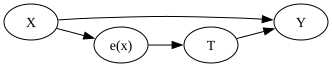

In [63]:
import graphviz as gr

g = gr.Digraph(graph_attr={"rankdir":"LR"})
g.edge("T", "Y")
g.edge("X", "Y")
g.edge("X", "e(x)")
g.edge("e(x)", "T")

g

- El **Propensity Score** es la probabilidad de recibir el tratamiento ($T=1$) dado un conjunto de covariables $X$:  
    $$
    e(x) = P(T=1 \mid X=x)
    $$

- **Intuición:** En vez de igualar a las personas en todas las variables, basta con igualarlas en su probabilidad de ser tratadas.

- **Reducción de dimensionalidad:** Resume toda la información de los confusores en un solo número entre 0 y 1.

- **Propiedad clave:** Si dos personas tienen el mismo $e(x)$, la asignación al tratamiento es "como si fuera aleatoria" entre ellas.

- **Independencia condicional:**  
    $$
    (Y_1, Y_0) \perp T \mid e(X)
    $$
    Es decir, dado el propensity score, el tratamiento es independiente de los potenciales resultados.



## Propensity Score Estimation

In [64]:
ps_model = smf.logit("""
    intervention ~ tenure + last_engagement_score + department_score
    + C(n_of_reports) + C(gender) + C(role)""", data=df.to_pandas()).fit(disp=0)

In [65]:
data_ps = df.with_columns(
    propensities=pl.Series(ps_model.predict(df.to_pandas())),
)

data_ps.select(["intervention", "engagement_score", "propensities"]).head(10)

intervention,engagement_score,propensities
i64,f64,f64
1,0.277359,0.596106
1,-0.449646,0.391138
1,0.769703,0.602578
1,-0.121763,0.58099
1,1.526147,0.619976
1,0.009607,0.57002
1,1.743033,0.653871
1,0.953294,0.695098
1,2.36778,0.60347


## Propensity Score an Orthogonalization

In [66]:
model = smf.ols("engagement_score ~ intervention + propensities",
    data=data_ps.to_pandas()).fit()
float(model.params["intervention"])

0.2633126749027772

- **¿Qué es el Propensity Score?**
  - Es la probabilidad condicional de recibir el tratamiento dado los confusores:  
    $$
    e(x) = P(T=1 \mid X=x)
    $$
- **¿Cómo se calcula?**
  - Usualmente mediante regresión logística:
    $$
    \log\left(\frac{e(x)}{1 - e(x)}\right) = \beta_0 + \beta_1 X_1 + \cdots + \beta_k X_k
    $$
- **Ventajas clave:**
  - **Reducción de dimensionalidad:** Resume todos los confusores $X$ en un solo número.
  - **Balanceo:** Si igualas en $e(x)$, igualas en la distribución de $X$ entre tratados y controles.
  - **Flexibilidad:** Permite usar técnicas de matching, weighting o estratificación para estimar el ATE.
  - **Captura relaciones no lineales:** Si usas modelos no lineales para estimar $e(x)$, puedes capturar relaciones complejas entre $X$ y $T$.

## Propensity Score Matching

In [67]:
from sklearn.neighbors import KNeighborsRegressor

T = "intervention"
X = "propensities"
Y = "engagement_score"

treated = data_ps.filter(pl.col(T) == 1)
control = data_ps.filter(pl.col(T) == 0)

mt0 = KNeighborsRegressor(n_neighbors=1).fit(
    control.select(X).to_numpy(),
    control.select(Y).to_numpy().ravel()
)
mt1 = KNeighborsRegressor(n_neighbors=1).fit(
    treated.select(X).to_numpy(),
    treated.select(Y).to_numpy().ravel()
)

predicted = pl.concat([
    treated.with_columns(
        match=pl.Series(mt0.predict(treated.select(X).to_numpy()))
    ),
    control.with_columns(
        match=pl.Series(mt1.predict(control.select(X).to_numpy()))
    )
])

predicted.head()

departament_id,intervention,engagement_score,tenure,n_of_reports,gender,role,last_engagement_score,department_score,department_size,propensities,match
i64,i64,f64,i64,i64,i64,i64,f64,f64,i64,f64,f64
76,1,0.277359,6,4,2,4,0.614261,0.224077,843,0.596106,0.55768
76,1,-0.449646,4,8,2,4,0.069636,0.224077,843,0.391138,-0.952622
76,1,0.769703,6,4,2,4,0.866918,0.224077,843,0.602578,-0.618381
76,1,-0.121763,6,4,2,4,0.029071,0.224077,843,0.58099,-1.404962
76,1,1.526147,6,4,1,4,0.589857,0.224077,843,0.619976,0.000354


In [68]:

ate = (
    (predicted.with_columns(
        ate=((pl.col(Y) - pl.col("match"))*(pl.col(T))
        + (pl.col("match") - pl.col(Y))*(1-pl.col(T))))
    ).select("ate").mean().item()
)
print("ATE:", ate)

ATE: 0.2877744347404597


## Inverse Propensity Weightin

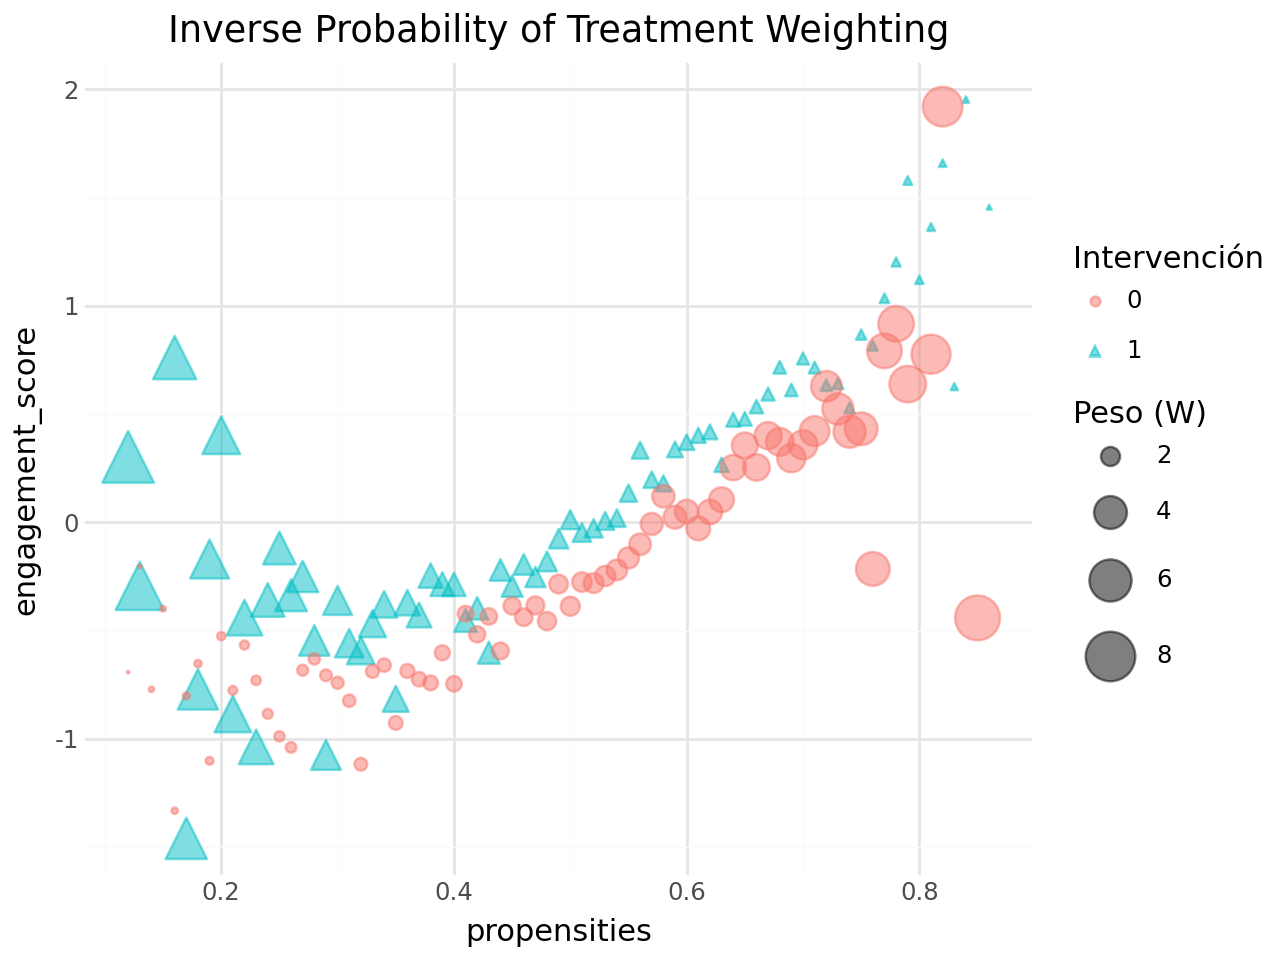

In [69]:
from plotnine import *


plot_df =data_ps.with_columns(
    w=pl.when(pl.col("intervention") == 1)
    .then(1 / pl.col("propensities"))
    .otherwise(1 / (1 - pl.col("propensities"))),
    propensities=pl.col("propensities").round(2)
).group_by(["propensities", "intervention"]).agg(
    pl.mean("engagement_score").alias("engagement_score"),
    pl.mean("w").alias("w")
).sort(["propensities"])

(
    ggplot(plot_df, aes(x="propensities", y="engagement_score",
                        color="factor(intervention)", shape="factor(intervention)")) +
    geom_point(aes(size="w"), alpha=0.5) +
    scale_shape_manual(values=["o", "^"]) +  # Círculo para T=0, triángulo para T=1
    scale_size_area(max_size=10) +
    labs(title="Inverse Probability of Treatment Weighting",
         x="propensities",
         y="engagement_score",
         shape="Intervención",
         color="Intervención",
         size="Peso (W)") +
    theme_minimal()
)

In [70]:
# Extraemos los grupos tratados y control
treated = data_ps.filter(pl.col("intervention") == 1)
control = data_ps.filter(pl.col("intervention") == 0)

# Obtenemos las series de propensities y engagement_score
prop_t = treated.get_column("propensities")
prop_c = control.get_column("propensities")
y_t = treated.get_column("engagement_score")
y_c = control.get_column("engagement_score")

# Calculamos los pesos IPTW
w_t = 1 / prop_t
w_c = 1 / (1 - prop_c)

# Calculamos el promedio ponderado en cada grupo
E_Y1 = (y_t * w_t).sum() / w_t.sum()
E_Y0 = (y_c * w_c).sum() / w_c.sum()

print("E[Y(1)]:", E_Y1)
print("E[Y(0)]:", E_Y0)
print("ATE:", E_Y1 - E_Y0)

E[Y(1)]: 0.11607068367916587
E[Y(0)]: -0.14994514399967188
ATE: 0.26601582767883775


In [71]:
data_ps.with_columns(
    ate=pl.col("engagement_score") * (pl.col("intervention") - pl.col("propensities"))
    / (pl.col("propensities") * (1 - pl.col("propensities")))
).select("ate").mean().item()

0.265978708807612

## Variance of IPW

In [72]:
from sklearn.linear_model import LogisticRegression 
from patsy import dmatrix

# deine la función que computa el estimador de IPW
def est_ate_with_ps(df, ps_formula, T, Y):

    # fit the propensity score model
    X = dmatrix(ps_formula, df)
    ps_model = LogisticRegression(penalty=None,
                                  max_iter=1000).fit(X, df[T])
    ps = ps_model.predict_proba(X)[:, 1]

    # compute the ATE
    return float(np.mean((df[T]-ps) / (ps*(1-ps)) * df[Y]) )

In [73]:
formula = """tenure + last_engagement_score + department_score
         + C(n_of_reports) + C(gender) + C(role)"""
T = "intervention"
Y = "engagement_score"

est_ate_with_ps(df.to_pandas(), formula, T, Y)

0.26597964346216624

In [74]:
from joblib import Parallel, delayed # for parallel processing
def bootstrap(data, est_fn, rounds=200, seed=123, pcts=[2.5, 97.5]):
    
    np.random.seed(seed)

    
    stats = Parallel(n_jobs=16)(
    delayed(est_fn)(data.sample(frac=1, replace=True))
    for _ in range(rounds))
    return np.percentile(stats, pcts)

In [75]:
from toolz import partial

print(f"ATE: {est_ate_with_ps(df.to_pandas(), formula, T, Y)}")
est_fn = partial(est_ate_with_ps, ps_formula=formula, T=T, Y=Y)
print(f"95% C.I.: ", bootstrap(df.to_pandas(), est_fn))

ATE: 0.26597964346216624
95% C.I.:  [0.2266428  0.30071831]


## Stabilized Propensity Weights

In [76]:
print("Original Sample Size:", df.height)
print("Treated Pseaudo-Population Sample Size", sum(w_t))
print("Untreated Pseaudo-Population Sample Size", sum(w_c))

Original Sample Size: 10391
Treated Pseaudo-Population Sample Size 10435.089079197922
Untreated Pseaudo-Population Sample Size 10354.298899788271


In [77]:
p_of_t = data_ps.select(pl.col("intervention").mean()).item()

t1 = data_ps.filter(pl.col("intervention") == 1)
t0 = data_ps.filter(pl.col("intervention") == 0)

weight_t_stable = p_of_t / t1.select(pl.col("propensities")).to_numpy().ravel()
weight_nt_stable = (1 - p_of_t) / (1 - t0.select(pl.col("propensities")).to_numpy().ravel())

print("Treat Size:", len(t1))
print("W treat", sum(weight_t_stable))

print("Control Size:", len(t0))
print("W control", sum(weight_nt_stable))

Treat Size: 5611
W treat 5634.807508745978
Control Size: 4780
W control 4763.116999421415


In [78]:
p_of_t

0.5399865268020402

In [79]:
nt = len(t1)
nc = len(t0)

y1 = sum(t1.select(pl.col("engagement_score")).to_numpy().ravel()
         * weight_t_stable) / nt
y0 = sum(t0.select(pl.col("engagement_score")).to_numpy().ravel()
         * weight_nt_stable) / nc

print("ATE Stable:", y1 - y0)

ATE Stable: 0.2659787088076116


## Pseudo Populations

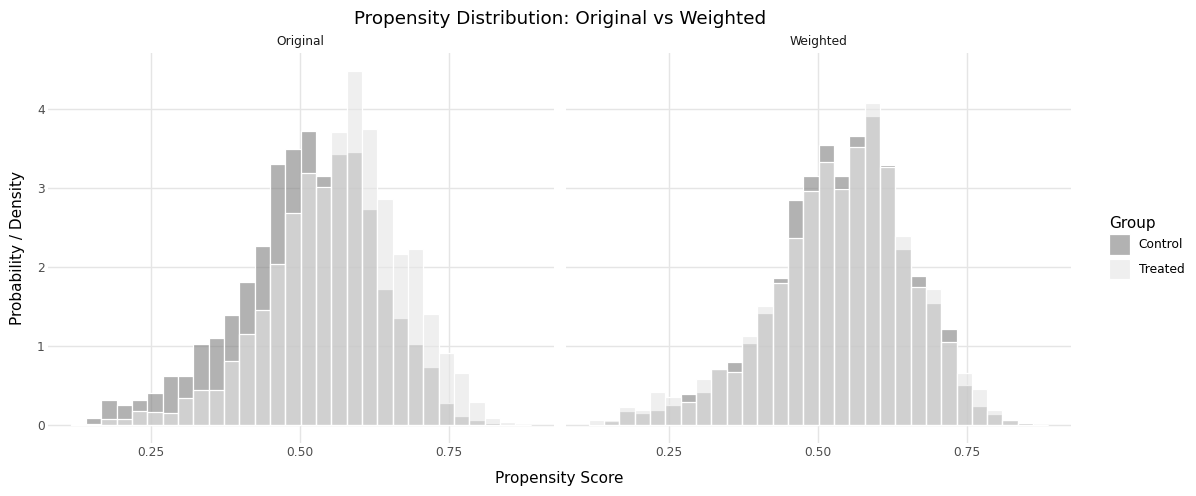

In [80]:
plot_df =data_ps.with_columns(
    w_stable=pl.when(pl.col("intervention") == 1)
    .then(p_of_t / pl.col("propensities"))
    .otherwise((1 - p_of_t) / (1 - pl.col("propensities"))),
)

# 1. PREPARACIÓN DE DATOS CON POLARS
# Creamos dos versiones del DF y las concatenamos
viz_df = pl.concat([
    # Versión Original: El peso es 1 para todos
    plot_df.select([
        "propensities", 
        "intervention",
        pl.lit(1.0).alias("weight_val"),
        pl.lit("Original").alias("tipo_distribucion")
    ]),
    
    # Versión Ponderada: El peso es w_stable
    plot_df.select([
        "propensities", 
        "intervention",
        pl.col("w_stable").alias("weight_val"),
        pl.lit("Weighted").alias("tipo_distribucion")
    ])
])

# 2. VISUALIZACIÓN CON PLOTNINE
(
    ggplot(viz_df, aes(x="propensities", fill="factor(intervention)", weight="weight_val"))
    + geom_histogram(
        aes(y=after_stat('density')), # Normaliza para que sean comparables
        alpha=0.6, 
        position="identity", # Superpone los histogramas en lugar de apilarlos
        bins=30,
        color="white" # Borde blanco para separar barras como en tu imagen
    )
    + facet_wrap("~tipo_distribucion") # <--- Esto crea los dos paneles lado a lado
    + scale_fill_manual(
        values=["#808080", "#E5E5E5"], # Colores gris oscuro y gris claro (como la imagen)
        labels=["Control", "Treated"]
    )
    + labs(
        title="Propensity Distribution: Original vs Weighted",
        x="Propensity Score",
        y="Probability / Density",
        fill="Group"
    )
    + theme_minimal()
    + theme(
        panel_grid_minor=element_blank(),
        figure_size=(12, 5) # Ajustar tamaño (ancho, alto)
    )
).draw()

- La **pseudo-población** es una muestra reponderada donde el tratamiento parece asignado al azar, corrigiendo el sesgo de confusión.
- El **IPW (Inverse Probability Weighting)** asigna pesos altos a individuos tratados con baja probabilidad de tratamiento y pesos bajos a los tratados con alta probabilidad, equilibrando la distribución de los confusores $X$ entre grupos.
- Tras ponderar, la distribución del propensity score $e(X)$ es similar en tratados y controles, simulando un experimento aleatorio.
- En la pseudo-población, cualquier diferencia en $Y$ entre tratados y controles se atribuye al tratamiento, no a $X$.
- El estimador IPW de la diferencia de medias ponderadas es insesgado para el ATE, bajo el supuesto de no-confusión no observada.
- Ponderar por $1/e(X)$ estima $E[Y(1)]$ (todos tratados); ponderar por $1/(1-e(X))$ estima $E[Y(0)]$ (nadie tratado); su diferencia es el ATE.

### Selection Bias and IPW

**1. ¿Qué es el sesgo de selección?**  
El sesgo de selección ocurre cuando la probabilidad de que una unidad sea incluida en la muestra ($R=1$) depende de variables $X$ que también afectan el resultado $Y$. Esto rompe la representatividad y puede sesgar cualquier estimación causal.

**2. ¿Cómo corrige IPW el sesgo de selección?**  
La idea es reponderar cada observación por el inverso de su probabilidad de ser observada, es decir, por $1/P(R=1|X)$. Así, las personas con baja probabilidad de ser observadas (pero que sí lo fueron) representan a muchas como ellas que no fueron observadas.

**3. ¿Qué pasa si hay confusión y selección?**  
Cuando el tratamiento $T$ y la selección $R$ dependen de $X$, necesitas ajustar por ambos mecanismos. El peso estabilizado generalizado es:

$$
W_i = \frac{P(T = t)}{P(T = t \mid X_i) \cdot P(R = 1 \mid X_i)}
$$

**Donde:**
- $T$ = variable de tratamiento (por ejemplo, intervención)
- $t$ = valor observado de $T$ para el individuo $i$ (usualmente 0 o 1)
- $X_i$ = vector de covariables para el individuo $i$
- $R$ = indicador de selección ($R=1$ si la unidad es observada)
- $P(T = t)$ = probabilidad marginal de tratamiento (en la población)
- $P(T = t \mid X_i)$ = probabilidad condicional de tratamiento dado $X_i$ (propensity score)
- $P(R = 1 \mid X_i)$ = probabilidad de ser observado dado $X_i$ (modelo de selección)



## Positivity

In [81]:
np.random.seed(1)

n = 1000
x = np.random.normal(0, 1, n)
t = np.random.normal(x, 0.5, n) > 0

y0 = -x 
y1 = y0 + t # ate = 1Q

y = np.random.normal((1-t)*y0 + t*y1, 0.2)

df_no_pos = pl.DataFrame(dict(
    x=x,
    t=t.astype(int),
    y=y
))

df_no_pos.head()

x,t,y
f64,i64,f64
1.624345,1,-0.526442
-0.611756,0,0.659516
-0.528172,0,0.438549
-1.072969,0,0.95081
0.865408,1,-0.271397


C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\plotnine\themes\themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


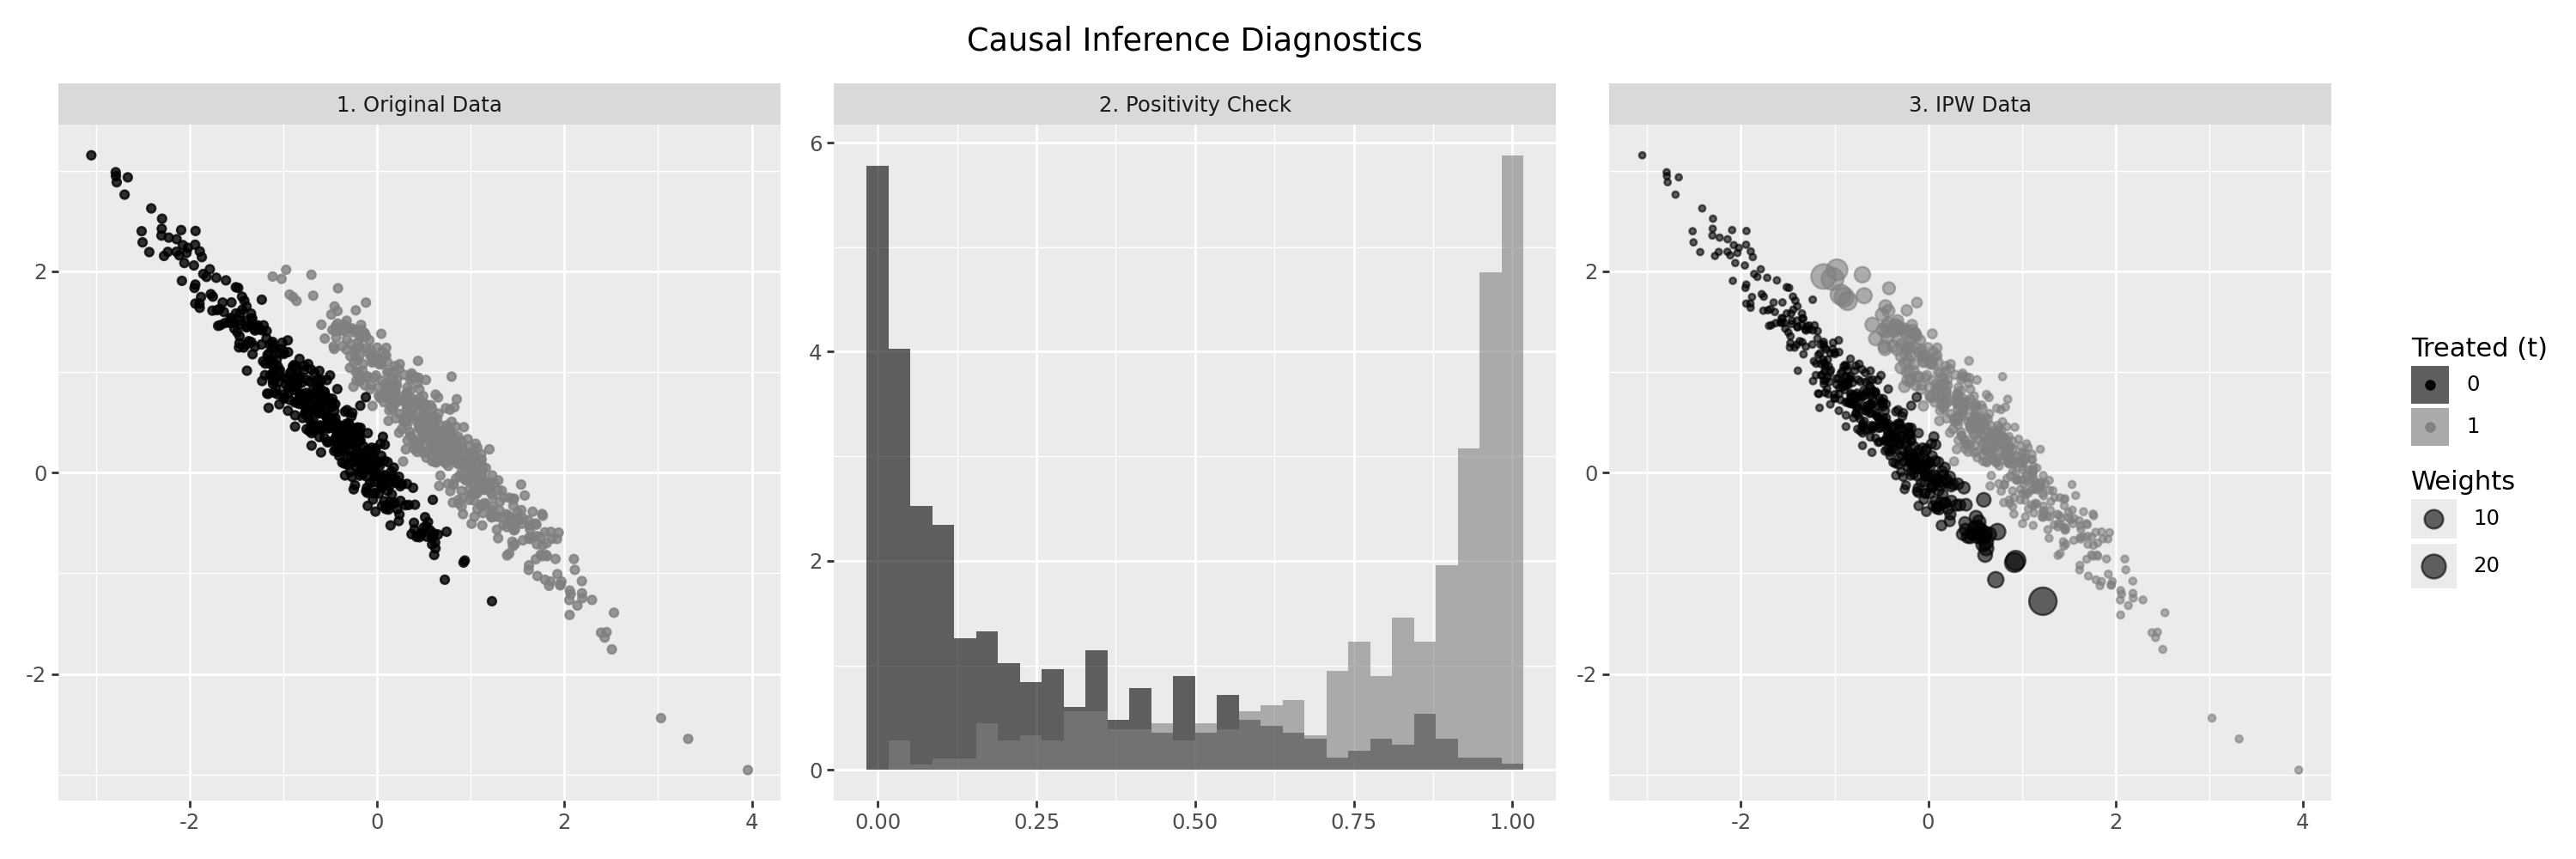

In [82]:
df_no_pos = pl.DataFrame({"x": x, "t": t.astype(int), "y": y})

# Modelo de Propensity Score
# (Statsmodels requiere pandas, es el único paso no-Polars inevitable para el logit)
ps_model = smf.logit("t ~ x", data=df_no_pos.to_pandas()).fit(disp=0)

# Cálculos en Polars puro
df_final = df_no_pos.with_columns(
    ps = pl.Series(ps_model.predict(df_no_pos.to_pandas()))
).with_columns(
    # Cálculo de Stabilized Weights
    weights = pl.when(pl.col("t") == 1)
              .then(pl.col("t").mean() / pl.col("ps"))
              .otherwise((1 - pl.col("t").mean()) / (1 - pl.col("ps"))),
    # Convertimos t a string para colores discretos
    t_cat = pl.col("t").cast(pl.String)
)

# Convertimos a Pandas para pasar a Plotnine
df_plot = df_final

# --- 2. GRAFICADO AVANZADO CON FACET WRAP ---
# Truco: Usamos un ggplot base vacío y agregamos 'geoms' con datos filtrados
# simulando paneles mediante una columna artificial 'panel_name'.

(
    ggplot()
    # PANEL 1: Original Data (Scatter)
    + geom_point(
        data=df_plot.with_columns(panel_name=pl.lit("1. Original Data")), 
        mapping=aes(x='x', y='y', color='t_cat'),
        alpha=0.8
    )
    # PANEL 2: Positivity Check (Histograma)
    # Nota: Mapeamos 'ps' al eje x, y 'density' al eje y.
    + geom_histogram(
        data=df_plot.with_columns(panel_name=pl.lit("2. Positivity Check")), 
        mapping=aes(x='ps', fill='t_cat', y=after_stat('density')),
        position="identity", 
        alpha=0.6, 
        bins=30
    )
    # PANEL 3: IPW Data (Scatter con tamaño)
    + geom_point(
        data=df_plot.with_columns(panel_name=pl.lit("3. IPW Data")), 
        mapping=aes(x='x', y='y', color='t_cat', size='weights'),
        alpha=0.6
    )
    # CONFIGURACIÓN DE LOS PANELES
    # scales="free" permite que cada gráfico tenga sus propios rangos y ejes (clave aquí)
    + facet_wrap('~panel_name', scales="free", nrow=1)
    
    # ESTILOS Y COLORES
    + scale_color_manual(values=['black', 'gray'], name="Treated (t)")
    + scale_fill_manual(values=['black', 'gray'], name="Treated (t)")
    + scale_size_continuous(range=(1, 6), name="Weights")
    + labs(title="Causal Inference Diagnostics", x="", y="") # Quitamos etiquetas globales confusas
    + theme_gray()
    + theme(
        figure_size=(15, 5),          # Tamaño ancho tipo banner
        legend_position="right",      # Leyenda unificada a la derecha
        subplots_adjust={'wspace': 0.2} # Espacio entre paneles
    )
)


In [83]:
est_fn = partial(est_ate_with_ps, ps_formula="x", T="t", Y="y")
print("ATE:",  est_fn(df_no_pos.to_pandas()))
print(f"95% C.I.: ", bootstrap(df_no_pos.to_pandas(), est_fn))

ATE: 0.6483491345012087
95% C.I.:  [0.41730173 0.88892041]


In [84]:
smf.ols("y ~ t + x", data=df_no_pos.to_pandas()).fit().params["t"]

np.float64(1.01658554876795)

## Design- Versus Model-Based Identification

In [85]:
from sklearn.linear_model import LinearRegression

def doubly_robust(df, formula, T, Y):
    X = dmatrix(formula, df)
    
    ps_model = LogisticRegression(penalty=None,
                                  max_iter=1000).fit(X, df[T])
    ps = ps_model.predict_proba(X)[:, 1]
    
    m0 = LinearRegression().fit(X[df[T]==0, :], df.query(f"{T}==0")[Y])
    m1 = LinearRegression().fit(X[df[T]==1, :], df.query(f"{T}==1")[Y])
    
    m0_hat = m0.predict(X)
    m1_hat = m1.predict(X)

    return (
        np.mean(df[T]*(df[Y] - m1_hat)/ps + m1_hat) -
        np.mean((1-df[T])*(df[Y] - m0_hat)/(1-ps) + m0_hat)
    )

In [86]:
formula = "tenure + last_engagement_score + department_score + C(n_of_reports) + C(gender) + C(role)"

T = "intervention"
Y = "engagement_score"

print("Doubly Robust ATE:", doubly_robust(df.to_pandas(), formula, T, Y))
est_fn  = partial(doubly_robust, formula=formula, T=T, Y=Y)
print(f"95% C.I.: ", bootstrap(df.to_pandas(), est_fn))

Doubly Robust ATE: 0.27117362002979517
95% C.I.:  [0.2300741  0.30521421]


## Treatment is Easy to Model

Propensity Score follows:

$$
e(x) = 1 / (1 + \exp(-(1-1.5x)))
$$

In [87]:
np.random.seed(123)

n = 10000
x = np.random.beta(1,1, n).round(2)*2
e = 1/(1+np.exp(-(1+1.5*x)))
t = np.random.binomial(1, e)

y1 = 1
y0 = 1 - 1*x**3
y = t*(y1) + (1-t)*y0 + np.random.normal(0, 1, n)

df_easy_t = pl.DataFrame(dict(y=y, x=x, t=t))

print("True ATE:", np.mean(y1-y0))

True ATE: 2.0056243152


True ATE: 2.0056243152


C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\plotnine\themes\themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


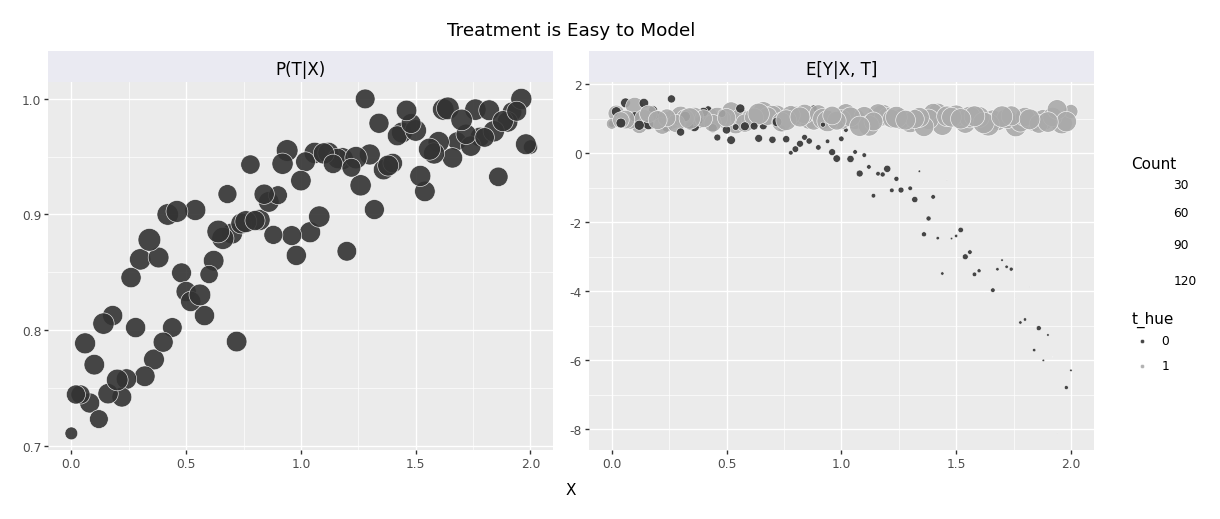

In [88]:
import polars as pl
import numpy as np
from plotnine import *

# --- 1. Generación de Datos (TU CÓDIGO ORIGINAL EXACTO) ---
np.random.seed(123)
n = 10000
x = np.random.beta(1, 1, n).round(2) * 2

# Fórmula corregida según tu snippet: (1 + 1.5 * x)
e = 1 / (1 + np.exp(-(1 + 1.5 * x))) 
t = np.random.binomial(1, e)

y1 = 1
y0 = 1 - 1 * x**3

# Ruido corregido: 1 (antes tenías 0.1, por eso no se veía disperso)
y = t * (y1) + (1 - t) * (y0) + np.random.normal(0, 1, n)

# Creamos DataFrame base
df_easy_t = pl.DataFrame(dict(x=x, t=t, y=y))

print("True ATE:", np.mean(y1 - y0)) 

# --- 2. Preparación de Datos (Imitando tu groupby) ---

# Panel Izquierdo: P(T|X)
# Seaborn: .agg({"size":"sum", "t":"mean"})
# Nota: En tu plot original, el panel izq NO tiene 'hue', así que todos son negros (t=0)
df_left = (
    df_easy_t.group_by("x")
    .agg(
        pl.col("t").mean().alias("y_val"), # Eje Y es probabilidad
        pl.len().alias("count")            # Tamaño
    )
    .with_columns(
        pl.lit("0").alias("t_hue"),        # Forzamos color negro
        pl.lit("P(T|X)").alias("panel")
    )
    .select(["x", "y_val", "count", "t_hue", "panel"])
)

# Panel Derecho: E[Y|X, T]
# Seaborn: .agg({"size":"sum", "y":"mean"}) con hue="t"
df_right = (
    df_easy_t.group_by(["x", "t"])
    .agg(
        pl.col("y").mean().alias("y_val"), # Eje Y es Outcome
        pl.len().alias("count")            # Tamaño
    )
    .with_columns(
        pl.col("t").cast(pl.Utf8).alias("t_hue"), # Color según T
        pl.lit("E[Y|X, T]").alias("panel")
    )
    .select(["x", "y_val", "count", "t_hue", "panel"])
)

# Unimos
plot_df = pl.concat([df_left, df_right])

# Ordenamos Paneles
try:
    plot_df = plot_df.with_columns(
        pl.col("panel").cast(pl.Enum(["P(T|X)", "E[Y|X, T]"]))
    )
except:
    # Fallback para versiones viejas
    plot_df = plot_df.with_columns(pl.col("panel").cast(pl.Categorical))

# --- 3. Visualización Idéntica a Seaborn ---

(
    ggplot(plot_df, aes(x="x", y="y_val", size="count", fill="t_hue"))
    
    # GEOMETRÍA:
    # stroke=0.25 y color="white" crean el borde blanco fino típico de Seaborn
    + geom_point(color="white", stroke=0.25, alpha=0.9)
    
    # PANELES:
    + facet_wrap("~panel", scales="free")
    
    # TAMAÑOS:
    # Seaborn sizes=(1, 100) es área. scale_size_area replica esto.
    # max_size=9 da ese look de burbuja grande.
    + scale_size_area(max_size=9)
    
    # COLORES:
    # 0 = Negro (Izquierda y puntos de control derecha)
    # 1 = Gris Claro (Puntos de tratamiento derecha)
    + scale_fill_manual(values={"0": "#333333", "1": "#AAAAAA"})
    
    # TEMA:
    + theme_gray()
    + theme(
        figure_size=(12, 5),
        subplots_adjust={'wspace': 0.25},
        legend_position="right",
        
        # Estilo de los títulos de paneles
        strip_background=element_rect(fill="#EAEAF2"),
        strip_text=element_text(size=12, color="black"),
        
        # Limpieza de leyenda
        legend_key=element_blank()
    )
    + guides(fill=None) # Ocultar leyenda de color (ya se entiende por el gráfico)
    + labs(
        title="Treatment is Easy to Model",
        y="", # Seaborn quita el nombre del eje Y en el facet
        x="X",
        size="Count"
    )
).draw()

In [89]:
m0 = smf.ols("y~x", data=df_easy_t.to_pandas().query("t==0")).fit()
m1 = smf.ols("y~x", data=df_easy_t.to_pandas().query("t==1")).fit()
regr_ate = (m1.predict(df_easy_t.to_pandas()) -
            m0.predict(df_easy_t.to_pandas())).mean()
print("Regression ATE:", regr_ate)

Regression ATE: 1.786678396833024


In [90]:
df_right = (
    df_easy_t.group_by(["x", "t"])
    .agg(
        pl.col("y").mean().alias("y"), # Eje Y es Outcome
        pl.len().alias("count")            # Tamaño
    )
    .with_columns(
        pl.col("t").cast(pl.Utf8).alias("t"), # Color según T
    )
    .select(["x", "t", "y", "count"])
)

plot_df = df_right.with_columns(
    preds_t0=pl.Series(m0.predict(df_right.to_pandas())),
    preds_t1=pl.Series(m1.predict(df_right.to_pandas())),
)
plot_df

x,t,y,count,preds_t0,preds_t1
f64,str,f64,u32,f64,f64
0.84,"""1""",1.137095,89,-0.351331,1.005165
1.78,"""1""",0.89265,88,-2.839818,0.982118
0.6,"""1""",1.004925,67,0.284027,1.011049
0.98,"""1""",0.942563,83,-0.721957,1.001732
0.36,"""0""",0.770588,23,0.919385,1.016933
…,…,…,…,…,…
0.52,"""1""",1.21915,80,0.495813,1.01301
1.98,"""1""",0.913989,98,-3.369283,0.977215
0.12,"""0""",0.8101,23,1.554744,1.022817


C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\plotnine\themes\themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


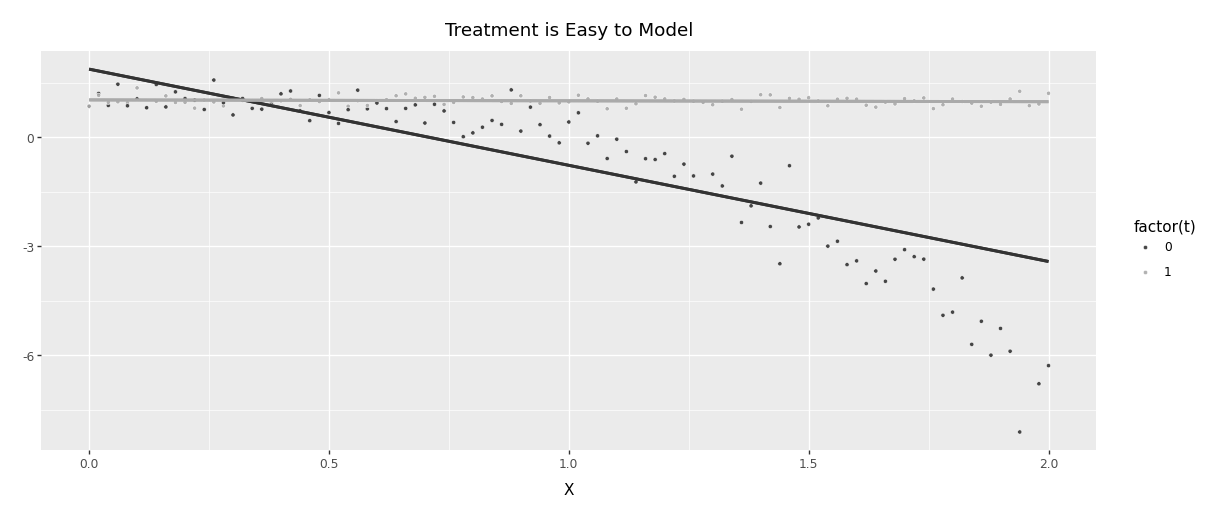

In [91]:
(
    ggplot(plot_df, aes(x="x", y="y", fill="factor(t)"))
    
    # GEOMETRÍA:
    # stroke=0.25 y color="white" crean el borde blanco fino típico de Seaborn
    + geom_point(color="white", stroke=0.25, alpha=0.9)

    + geom_line(aes(y="preds_t0"), color="#333333", size=1.2)
    + geom_line(aes(y="preds_t1"), color="#AAAAAA", size=1.2)
    
    # TAMAÑOS:
    # Seaborn sizes=(1, 100) es área. scale_size_area replica esto.
    # max_size=9 da ese look de burbuja grande.
    + scale_size_area(max_size=9)
    
    # COLORES:
    # 0 = Negro (Izquierda y puntos de control derecha)
    # 1 = Gris Claro (Puntos de tratamiento derecha)
    + scale_fill_manual(values={"0": "#333333", "1": "#AAAAAA"})
    
    # TEMA:
    + theme_gray()
    + theme(
        figure_size=(12, 5),
        subplots_adjust={'wspace': 0.25},
        legend_position="right",
        
        # Estilo de los títulos de paneles
        strip_background=element_rect(fill="#EAEAF2"),
        strip_text=element_text(size=12, color="black"),
        
        # Limpieza de leyenda
        legend_key=element_blank()
    )
    + guides(fill=None) # Ocultar leyenda de color (ya se entiende por el gráfico)
    + labs(
        title="Treatment is Easy to Model",
        y="", # Seaborn quita el nombre del eje Y en el facet
        x="X",
        size="Count"
    )
).draw()

In [92]:
m = smf.ols("y~t*(x + np.power(x, 3))", data=df_easy_t.to_pandas()).fit()
regr_ate = (m.predict(df_easy_t.with_columns(t=pl.lit(1)).to_pandas()) -
            m.predict(df_easy_t.with_columns(t=pl.lit(0)).to_pandas())).mean()
print("Regression ATE:", regr_ate)

Regression ATE: 1.9970999747189861


In [93]:
est_fn = partial(est_ate_with_ps, ps_formula="x", T="t", Y="y")
print("Propensity Score ATE:",  est_fn(df_easy_t.to_pandas()))
print(f"95% C.I.: ", bootstrap(df_easy_t.to_pandas(), est_fn))

Propensity Score ATE: 2.0000995686479537
95% C.I.:  [1.81133665 2.22613056]


In [94]:
est_dn = partial(doubly_robust, formula="x", T="t", Y="y")
print("DR ATE:",  est_dn(df_easy_t.to_pandas()))
print(f"95% C.I.: ", bootstrap(df_easy_t.to_pandas(), est_dn))

DR ATE: 2.0010131305548926
95% C.I.:  [1.87190613 2.14533967]


### Outcome Is Easy to Model

In [95]:
np.random.seed(123)

n = 10000
x = np.random.beta(1,1, n).round(2)*2
e = 1/(1+np.exp(-(2*x - x**3)))
t = np.random.binomial(1, e)

y1 = x
y0 = y1 + 1 # ate of -1
y = t*(y1) + (1-t)*y0 + np.random.normal(0, 1, n)

df_easy_y = pl.DataFrame(dict(y=y, x=x, t=t))

print("True ATE:", np.mean(y1-y0))

True ATE: -1.0


True ATE: -1.0


C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\plotnine\themes\themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


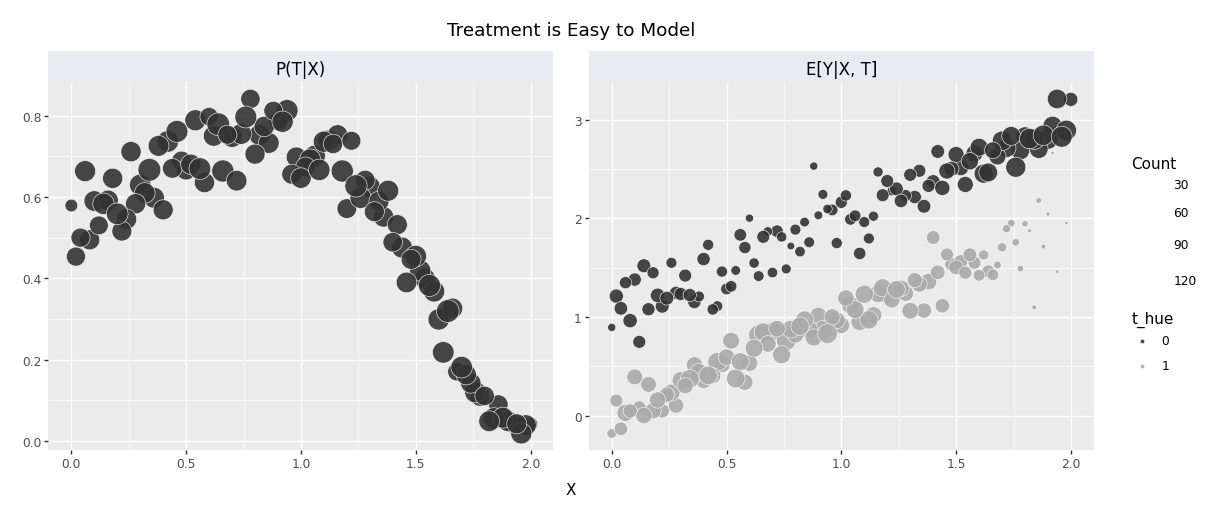

In [96]:
import polars as pl
import numpy as np
from plotnine import *

# --- 1. Generación de Datos (TU CÓDIGO ORIGINAL EXACTO) ---
np.random.seed(123)

n = 10000
x = np.random.beta(1,1, n).round(2)*2
e = 1/(1+np.exp(-(2*x - x**3)))
t = np.random.binomial(1, e)

y1 = x
y0 = y1 + 1 # ate of -1
y = t*(y1) + (1-t)*y0 + np.random.normal(0, 1, n)

df_easy_y = pl.DataFrame(dict(y=y, x=x, t=t))

print("True ATE:", np.mean(y1-y0))

# --- 2. Preparación de Datos (Imitando tu groupby) ---

# Panel Izquierdo: P(T|X)
# Seaborn: .agg({"size":"sum", "t":"mean"})
# Nota: En tu plot original, el panel izq NO tiene 'hue', así que todos son negros (t=0)
df_left = (
    df_easy_y.group_by("x")
    .agg(
        pl.col("t").mean().alias("y_val"), # Eje Y es probabilidad
        pl.len().alias("count")            # Tamaño
    )
    .with_columns(
        pl.lit("0").alias("t_hue"),        # Forzamos color negro
        pl.lit("P(T|X)").alias("panel")
    )
    .select(["x", "y_val", "count", "t_hue", "panel"])
)

# Panel Derecho: E[Y|X, T]
# Seaborn: .agg({"size":"sum", "y":"mean"}) con hue="t"
df_right = (
    df_easy_y.group_by(["x", "t"])
    .agg(
        pl.col("y").mean().alias("y_val"), # Eje Y es Outcome
        pl.len().alias("count")            # Tamaño
    )
    .with_columns(
        pl.col("t").cast(pl.Utf8).alias("t_hue"), # Color según T
        pl.lit("E[Y|X, T]").alias("panel")
    )
    .select(["x", "y_val", "count", "t_hue", "panel"])
)

# Unimos
plot_df = pl.concat([df_left, df_right])

# Ordenamos Paneles
try:
    plot_df = plot_df.with_columns(
        pl.col("panel").cast(pl.Enum(["P(T|X)", "E[Y|X, T]"]))
    )
except:
    # Fallback para versiones viejas
    plot_df = plot_df.with_columns(pl.col("panel").cast(pl.Categorical))

# --- 3. Visualización Idéntica a Seaborn ---

(
    ggplot(plot_df, aes(x="x", y="y_val", size="count", fill="t_hue"))
    
    # GEOMETRÍA:
    # stroke=0.25 y color="white" crean el borde blanco fino típico de Seaborn
    + geom_point(color="white", stroke=0.25, alpha=0.9)
    
    # PANELES:
    + facet_wrap("~panel", scales="free")
    
    # TAMAÑOS:
    # Seaborn sizes=(1, 100) es área. scale_size_area replica esto.
    # max_size=9 da ese look de burbuja grande.
    + scale_size_area(max_size=9)
    
    # COLORES:
    # 0 = Negro (Izquierda y puntos de control derecha)
    # 1 = Gris Claro (Puntos de tratamiento derecha)
    + scale_fill_manual(values={"0": "#333333", "1": "#AAAAAA"})
    
    # TEMA:
    + theme_gray()
    + theme(
        figure_size=(12, 5),
        subplots_adjust={'wspace': 0.25},
        legend_position="right",
        
        # Estilo de los títulos de paneles
        strip_background=element_rect(fill="#EAEAF2"),
        strip_text=element_text(size=12, color="black"),
        
        # Limpieza de leyenda
        legend_key=element_blank()
    )
    + guides(fill=None) # Ocultar leyenda de color (ya se entiende por el gráfico)
    + labs(
        title="Treatment is Easy to Model",
        y="", # Seaborn quita el nombre del eje Y en el facet
        x="X",
        size="Count"
    )
).draw()

In [97]:
est_fn = partial(est_ate_with_ps, ps_formula="x", T="t", Y="y")
print("Propensity Score ATE:",  est_fn(df_easy_y.to_pandas()))
print(f"95% C.I.: ", bootstrap(df_easy_y.to_pandas(), est_fn))

Propensity Score ATE: -1.1042787799722573
95% C.I.:  [-1.14324543 -1.06578745]


In [98]:
m0 = smf.ols("y~x", data=df_easy_y.to_pandas().query("t==0")).fit()
m1 = smf.ols("y~x", data=df_easy_y.to_pandas().query("t==1")).fit()
regr_ate = (m1.predict(df_easy_y.to_pandas()) - 
            m0.predict(df_easy_y.to_pandas())).mean()
print("Regression ATE:", regr_ate)

Regression ATE: -1.0008783612504355


#### DR

In [99]:
est_fn = partial(doubly_robust, formula="x", T="t", Y="y")
print("DR ATE:",  est_fn(df_easy_y.to_pandas()))
print(f"95% C.I.: ", bootstrap(df_easy_y.to_pandas(), est_fn))

DR ATE: -1.002845858106496
95% C.I.:  [-1.04156013 -0.96353435]


## Generalized Propensity Score for Continuous Treatment

In [100]:
df_cont_t = pl.read_csv("../data/interest_rate.csv")
df_cont_t.head()

ml_1,ml_2,interest,duration
f64,f64,f64,f64
0.392938,0.326285,7.1,12.0
-0.427721,0.679573,5.6,17.0
-0.546297,0.647309,11.1,12.0
0.10263,-0.264776,7.2,18.0
0.438938,-0.648818,9.5,19.0


In [101]:
m_naive = smf.ols("duration ~ interest", data=df_cont_t.to_pandas()).fit()
m_naive.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,14.5033,0.226,64.283,0.000,14.061,14.946
interest,0.3393,0.029,11.697,0.000,0.282,0.396


In [102]:
model_t = smf.ols("interest~ml_1 + ml_2", data=df_cont_t.to_pandas()).fit()
model_t.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,7.4803,0.020,377.532,0.000,7.441,7.519
ml_1,-0.9323,0.034,-27.128,0.000,-1.000,-0.865
ml_2,-0.9969,0.034,-28.996,0.000,-1.064,-0.930


La densidad de la distribución normal estada dada por l siguiente función:

$$
f(x|\mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$

donde:
- $x$ es el valor de la variable aleatoria.
- $\mu$ es la media de la distribución.
- $\sigma^2$ es la varianza de la distribución.


In [103]:
def conditional_density(x, mean, std):
    denom = std * np.sqrt(2 * np.pi)
    num = np.exp(-0.5 * ((x - mean) / std) ** 2)
    return (num / denom).ravel()

gps = conditional_density(
    df_cont_t.get_column("interest").to_numpy(),
    model_t.fittedvalues,
    np.std(model_t.resid)
)
gps

C:\Users\sergi\AppData\Local\Temp\ipykernel_7060\654085419.py:4: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.


array([0.1989118 , 0.14524168, 0.03338421, ..., 0.07339096, 0.19365006,
       0.15732008], shape=(10000,))

In [104]:
from scipy.stats import norm

gps = norm(loc=model_t.fittedvalues, scale=np.std(model_t.resid)).pdf(
    df_cont_t.get_column("interest").to_numpy()
)
gps

array([0.1989118 , 0.14524168, 0.03338421, ..., 0.07339096, 0.19365006,
       0.15732008], shape=(10000,))

In [105]:
final_model = smf.wls(
    "duration ~ interest + gps",
    data=df_cont_t.to_pandas(),
    weights=1 / gps
).fit()

final_model.params["interest"]

np.float64(-0.6669808233844955)

C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\plotnine\themes\themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


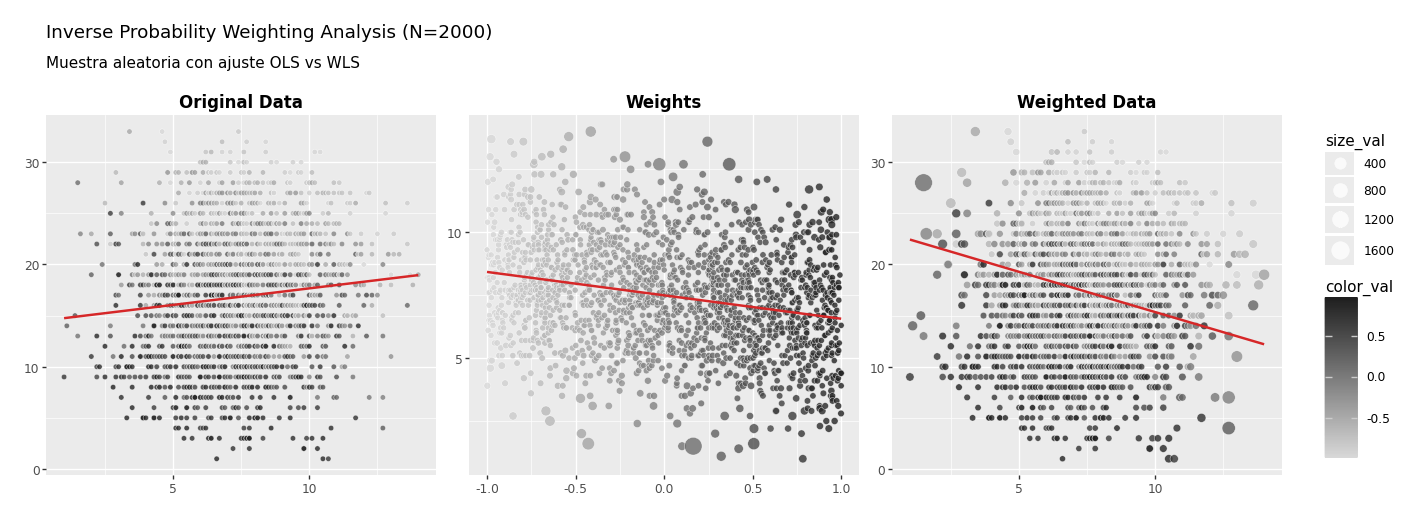

In [108]:
import polars as pl
import pandas as pd
import statsmodels.formula.api as smf
from plotnine import *

np.random.seed(1)

# --- 1. Muestreo y Preparación ---

# Asumimos que df_cont_t y gps existen en memoria.
# Primero unimos el gps al dataframe para que el sample mantenga la correspondencia
df_full = df_cont_t.with_columns(pl.Series(gps).alias("gps_score"))

# Tomamos el sample de 2000 filas
df_sample = df_full.sample(n=2000, seed=1) # seed para reproducibilidad

# Pasamos a Pandas para los modelos (Statsmodels lo requiere)
sample_pd = df_sample.to_pandas()
sample_pd["w"] = 1 / sample_pd["gps_score"] # Calculamos el peso inverso para el sample

# --- 2. Ajuste de Modelos (Sobre el Sample de 2000) ---

# A) Modelo Original (Duration ~ Interest)
m_ols = smf.ols("duration ~ interest", data=sample_pd).fit()

# B) Modelo Propensity (Interest ~ ML_1)
# Para la línea de tendencia del panel central
m_prop = smf.ols("interest ~ ml_1", data=sample_pd).fit()

# C) Modelo Ponderado (Duration ~ Interest [Weighted])
m_wls = smf.wls("duration ~ interest", data=sample_pd, weights=sample_pd["w"]).fit()

# Guardamos predicciones en el dataframe de pandas
sample_pd["pred_ols"] = m_ols.fittedvalues
sample_pd["pred_prop"] = m_prop.fittedvalues
sample_pd["pred_wls"] = m_wls.fittedvalues

# Regresamos a Polars para preparar los datos de la gráfica
df_proc = pl.from_pandas(sample_pd)

# --- 3. Preparación de Datos para Plotnine (Formato Largo) ---

# Panel 1: Original Data
df_p1 = (
    df_proc.sort("interest")
    .select(
        pl.col("interest").alias("x_val"),
        pl.col("duration").alias("y_val"),
        pl.col("pred_ols").alias("line_val"),
        pl.col("ml_1").alias("color_val"),
        pl.lit(1.0).alias("size_val"),
        pl.lit("Original Data").alias("panel")
    )
)

# Panel 2: Weights (ML_1 vs Interest)
df_p2 = (
    df_proc.sort("ml_1")
    .select(
        pl.col("ml_1").alias("x_val"),
        pl.col("interest").alias("y_val"),
        pl.col("pred_prop").alias("line_val"),
        pl.col("ml_1").alias("color_val"),
        pl.col("w").alias("size_val"),
        pl.lit("Weights").alias("panel")
    )
)

# Panel 3: Weighted Data
df_p3 = (
    df_proc.sort("interest")
    .select(
        pl.col("interest").alias("x_val"),
        pl.col("duration").alias("y_val"),
        pl.col("pred_wls").alias("line_val"),
        pl.col("ml_1").alias("color_val"),
        pl.col("w").alias("size_val"),
        pl.lit("Weighted Data").alias("panel")
    )
)

# Unir todo
plot_df = pl.concat([df_p1, df_p2, df_p3])

# Ordenar Paneles (Try/Except para compatibilidad de versiones Polars)
try:
    plot_df = plot_df.with_columns(
        pl.col("panel").cast(pl.Enum(["Original Data", "Weights", "Weighted Data"]))
    )
except:
    plot_df = plot_df.with_columns(pl.col("panel").cast(pl.Categorical))


# --- 4. Visualización ---

(
    ggplot(plot_df, aes(x="x_val", y="y_val"))
    
    # Puntos con borde blanco (Estilo Seaborn)
    + geom_point(
        aes(size="size_val", fill="color_val"), 
        color="white", stroke=0.2, alpha=0.8
    )
    
    # Líneas de regresión
    + geom_line(aes(y="line_val"), color="#D62728", size=1)
    
    # Facets
    + facet_wrap("~panel", scales="free", nrow=1)
    
    # Escalas sin 'guide=False' (usando guides() abajo)
    + scale_size_continuous(range=(2, 7)) 
    + scale_fill_gradient(low="#D9D9D9", high="#1F1F1F")
    
    # Ocultar leyendas de forma segura
    + guides(size=None, fill=None)
    
    # Tema
    + theme_gray()
    + theme(
        figure_size=(14, 5),
        subplots_adjust={'wspace': 0.20},
        strip_background=element_rect(fill="white"),
        strip_text=element_text(size=12, color="black", weight="bold"),
        axis_title=element_blank()
    )
    + labs(
        title="Inverse Probability Weighting Analysis (N=2000)",
        subtitle="Muestra aleatoria con ajuste OLS vs WLS"
    )
).draw()

In [110]:
stabilizer = norm(
    loc=df_cont_t["interest"].mean(),
    scale=np.std(df_cont_t.get_column("interest").to_numpy() - df_cont_t.get_column("interest").to_numpy().mean())
).pdf(df_cont_t.get_column("interest").to_numpy())

gipw =  stabilizer/gps

print("Original Sample Size:", len(df_cont_t))
print("Effective Stable Weights Sample Size:", sum(gipw))

Original Sample Size: 10000
Effective Stable Weights Sample Size: 9988.195951748603


La **ponderación estabilizada** para tratamientos continuos se define como:

$$
\text{Peso estabilizado} = \frac{f_T(t)}{f_{T|X}(t|x)}
$$

donde:

- $f_T(t)$ es la **densidad marginal** del tratamiento $T$ (cómo se distribuye $T$ en toda la muestra, sin condicionar en $X$).
- $f_{T|X}(t|x)$ es la **densidad condicional** del tratamiento dado las covariables $X$ (el Generalized Propensity Score, GPS).



In [111]:
final_model = smf.wls(
    "duration ~ interest + gps",
    data=df_cont_t.to_pandas(),
    weights=gipw
).fit()

final_model.params["interest"]

np.float64(-0.7784415159434526)

In [113]:
def gps_normal_ate(df, formula, T, Y, stable=True):
    mt = smf.ols(f"{T}~"+formula, data=df).fit()
    gps = norm(loc=mt.fittedvalues, scale=np.std(mt.resid)).pdf(df[T])
    stabilizer = norm(
        loc=df[T].mean(),
        scale=np.std(df[T] - df[T].mean())
    ).pdf(df[T])
    
    if stable:
        return smf.wls(f"{Y}~{T}", data=df, weights=stabilizer/gps).fit().params[T]
    else:
        return smf.wls(f"{Y}~{T}", data=df, weights=1/gps).fit().params[T]

print("95% CI, non-stable: ", bootstrap(df_cont_t.to_pandas(), partial(gps_normal_ate, formula="ml_1 + ml_2", T="interest", Y="duration", stable=False)))
print("95% CI, stable: ", bootstrap(df_cont_t.to_pandas(), partial(gps_normal_ate, formula="ml_1 + ml_2", T="interest", Y="duration")))

95% CI, non-stable:  [-0.81074164 -0.52605933]
95% CI, stable:  [-0.85834311 -0.71001914]


### Densidad marginal y densidad condicional: intuición y notación

- **Densidad marginal:**  
    La densidad marginal de $T$, denotada $f_T(t)$, responde a la pregunta:  
    > ¿Qué tan probable es observar $T = t$ en toda la muestra, sin condicionar en ninguna otra variable?

    Matemáticamente:
    $$
    f_T(t) = P(T = t)
    $$

- **Densidad condicional:**  
    La densidad condicional de $T$ dado $X$, denotada $f_{T|X}(t|x)$, responde a:  
    > ¿Qué tan probable es observar $T = t$ para individuos con características $X = x$?

    Matemáticamente:
    $$
    f_{T|X}(t|x) = P(T = t \mid X = x)
    $$

**Analogía EL5:**  
Imagina que tienes una bolsa con canicas rojas y azules ($T$).  
- La densidad marginal es la proporción de canicas rojas en toda la bolsa.  
- La densidad condicional es la proporción de canicas rojas, pero solo mirando las que están en una caja específica ($X = x$).



### Ideas Clave: Ponderación por Propensity Score vs. Ortogonalización

- **Ambas técnicas (regresión/ortogonalización e IPW) son herramientas fundamentales para ajustar sesgos en inferencia causal.**  
    Ambas requieren modelar el mecanismo de asignación del tratamiento, recordándonos la importancia de entender cómo se asigna el tratamiento en cualquier problema causal.

- **Ortogonalización:**  
    - "Residuabiliza" el tratamiento, proyectándolo en un espacio donde es independiente de los confusores $X$.
    - El objetivo es eliminar la correlación entre tratamiento y confusores, permitiendo estimar el efecto causal sin sesgo.

- **Inverse Propensity Weighting (IPW):**  
    - No cambia el tratamiento, sino que repondera los datos usando el inverso del propensity score:
        $$
        w = \frac{P(T)}{P(T|X)}
        $$
    - Así, simula una población donde el tratamiento es independiente de los confusores $X$.
    - Es especialmente útil cuando el tratamiento es **discreto**.

- **Comparación visual:**  
    - Ambos métodos pueden eliminar el sesgo de confusión y recuperar el efecto causal verdadero, pero lo hacen de formas conceptualmente distintas (ver Figura 5-1 del libro).

- **¿Cuál elegir?**  
    - **IPW** es preferible para tratamientos discretos, y aún mejor si se combina con modelos de resultado (enfoque "doblemente robusto").
    - **Modelos de resultado (regresión)** suelen ser más efectivos cuando el tratamiento es **continuo**, ya que IPW puede volverse inestable con pocos datos en cada valor de tratamiento.

- **Generalized Propensity Score (GPS):**  
    - Aunque IPW clásico es menos atractivo para tratamientos continuos, entender el GPS ayuda a profundizar la intuición sobre ponderación y sesgo.
    - En la práctica, para tratamientos continuos, suele ser más productivo asumir cierta suavidad en la función de respuesta al tratamiento y usar modelos paramétricos (como regresión lineal).

**Resumen:**  
Ambos métodos buscan eliminar el sesgo de confusión, pero lo hacen de maneras diferentes: ortogonalizando el tratamiento o reponderando la muestra. La elección depende del tipo de tratamiento y de la estabilidad de los métodos en el contexto de tus datos.

---
